In [27]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
import importlib
import processing, simulation
importlib.reload(simulation)
importlib.reload(processing)
from simulation import generate_time_vector, generate_glucose_signal
from processing import simulate_raw_sensor, moving_average

In [2]:
time = generate_time_vector()
glucose = generate_glucose_signal(time)
raw_sensor = simulate_raw_sensor(
    glucose,
    alpha=0.2,
    noise_std=3,
    sampling_interval_minutes=5,
    drift_rate=0.5,
    random_seed=42
)

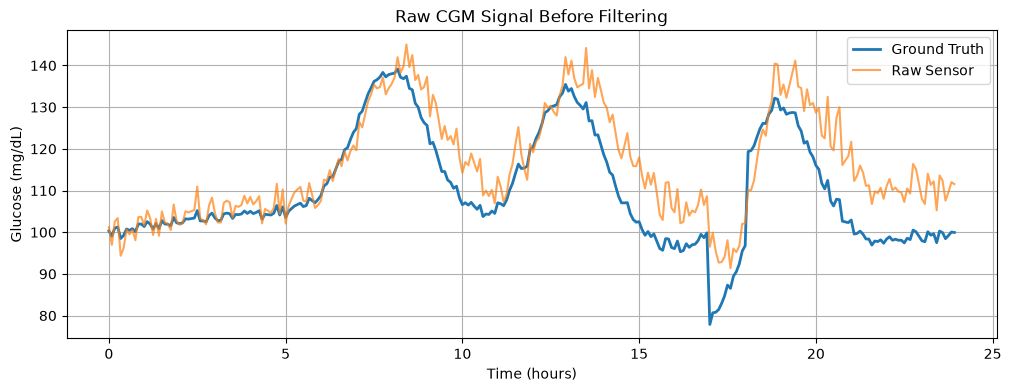

In [3]:
plt.figure(figsize=(12, 4))

plt.plot(
    time / 60,
    glucose,
    label="Ground Truth",
    linewidth=2,
)

plt.plot(
    time / 60,
    raw_sensor,
    label="Raw Sensor",
    alpha=0.7,
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Raw CGM Signal Before Filtering")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
filtered_sensor = moving_average(raw_sensor, window_size=5)

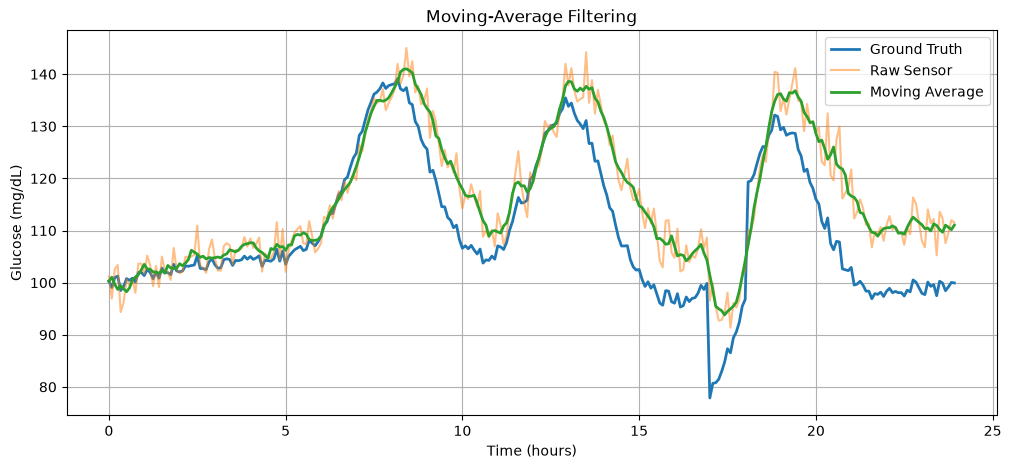

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    time / 60,
    glucose,
    label="Ground Truth",
    linewidth=2,
)

plt.plot(
    time / 60,
    raw_sensor,
    label="Raw Sensor",
    alpha=0.5,
)

plt.plot(
    time / 60,
    filtered_sensor,
    label="Moving Average",
    linewidth=2,
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Moving-Average Filtering")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
raw_rmse = np.sqrt(np.mean((raw_sensor - glucose)**2))
filtered_rmse = np.sqrt(np.mean((filtered_sensor - glucose)**2))

print(f"Raw sensor RMSE: {raw_rmse:.2f} mg/dL")
print(f"Filtered sensor RMSE: {filtered_rmse:.2f} mg/dL")

Raw sensor RMSE: 8.48 mg/dL
Filtered sensor RMSE: 8.38 mg/dL


In [20]:
window_sizes = [3, 5, 9, 15]

results = []

for window_size in window_sizes:
    filtered = moving_average(
        raw_sensor,
        window_size=window_size,
    )

    rmse = np.sqrt(
        np.mean((filtered - glucose) ** 2)
    )

    results.append({
        "window_size": window_size,
        "window_minutes": window_size*5,
        "RMSE": rmse
    })

In [21]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,window_size,window_minutes,RMSE
0,3,15,8.392429
1,5,25,8.376723
2,9,45,8.415322
3,15,75,8.535353


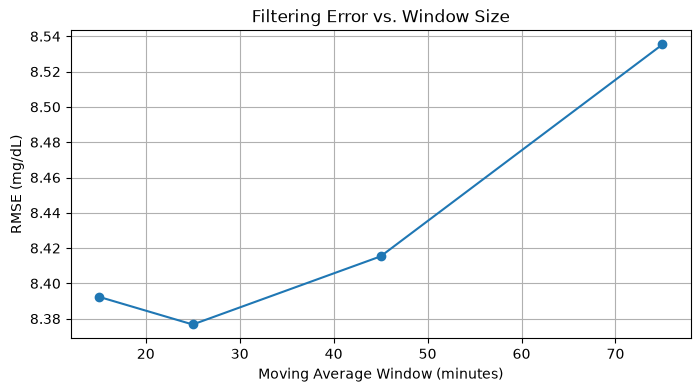

In [29]:
plt.figure(figsize=(8,4))

plt.plot(results_df['window_minutes'], results_df['RMSE'], marker = 'o')
plt.xlabel("Moving Average Window (minutes)")
plt.ylabel("RMSE (mg/dL)")
plt.title("Filtering Error vs. Window Size")
plt.grid(True)

plt.show()

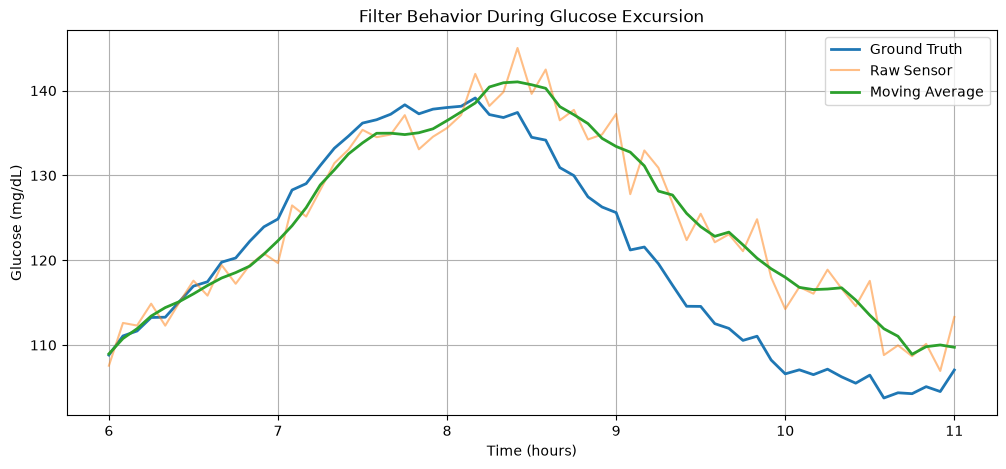

In [25]:
mask = (
    (time >= 6 * 60)
    & (time <= 11 * 60)
)

plt.figure(figsize=(12, 5))

plt.plot(
    time[mask] / 60,
    glucose[mask],
    label="Ground Truth",
    linewidth=2,
)

plt.plot(
    time[mask] / 60,
    raw_sensor[mask],
    label="Raw Sensor",
    alpha=0.5,
)

plt.plot(
    time[mask] / 60,
    filtered_sensor[mask],
    label="Moving Average",
    linewidth=2,
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Filter Behavior During Glucose Excursion")
plt.legend()
plt.grid(True)

plt.show()